# S&P 500 Equity Option Analytics: Label Engineering

**Chapter 7: Defining the Learning Task**
**Section Reference**: 7.2 - Label Engineering

This notebook implements label engineering for the **S&P 500 Equity Option Analytics**
case study. The strategy trades equities using options-derived signals, so labels
encode forward equity returns at horizons calibrated to the signal's persistence.

## Label Types
- **Primary**: 5-day forward return (1-week holding, matches weekly cadence)
- **Variant 1**: 10-day forward return (horizon exploration -- a longer horizon
  halves turnover and may capture slower-accruing VRP signal)
- **Variant 2**: Risk-adjusted forward return (return / trailing realized vol)
- **Binary**: Direction indicators for classification approaches

## Key Design Decisions
- Execution-consistent labels: features at t, enter at t+1 open, hold for h days
- 1-day IV lag enforced for point-in-time correctness
- Horizon exploration (5d vs 10d): the 5d baseline momentum IC computed below is
  weak, motivating a longer-horizon variant

## Output Contract

Artifacts saved to `case_studies/sp500_equity_option_analytics/labels/`:
- `fwd_ret_5d.parquet` - 5-day forward returns (primary)
- `fwd_ret_10d.parquet` - 10-day forward returns (critical variant)
- `fwd_ret_risk_adj_5d.parquet` - Risk-adjusted 5-day returns
- `fwd_dir_5d.parquet` - 5-day direction
- `fwd_dir_10d.parquet` - 10-day direction

Artifacts saved to repo root `case_studies/sp500_equity_option_analytics/`:
- `cv_config.json` - Walk-forward CV configuration

## Cross-References
- **Upstream**: Ch6 ([`01_feasibility_analysis`](01_feasibility_analysis.ipynb)) -- trading setup and protocol
- **Downstream**: Ch8 (`03_financial_features.py`), Ch9 (`04_temporal.py`), Ch11+ (ML pipeline)

In [1]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import polars as pl

import utils.style  # noqa: F401  (activates the ML4T matplotlib template)
from data import load_sp500_daily_bars
from utils.cv_splits import make_wf_config
from utils.paths import get_case_study_dir
from utils.style import ml4t_palette

In [2]:
CASE_STUDY_ID = "sp500_equity_option_analytics"
START_DATE = "2017-01-01"
END_DATE = "2021-12-31"
MAX_SYMBOLS = 0

In [3]:
# Configuration

CASE_DIR = get_case_study_dir("sp500_equity_option_analytics")
LABELS_DIR = CASE_DIR / "labels"

START_DATE = "2017-01-01"
END_DATE = "2021-12-31"
HOLDOUT_START = "2021-01-01"

# Label horizons (trading days)
PRIMARY_HORIZON = 5  # 1-week forward return
VARIANT_HORIZONS = [10]  # 2-week forward return (critical for viability)
ALL_HORIZONS = [PRIMARY_HORIZON] + VARIANT_HORIZONS

# Realized vol window for risk-adjusted labels
RV_WINDOW = 20  # 20-day realized vol

print(f"Date range: {START_DATE} to {END_DATE}")
print(f"Primary horizon: {PRIMARY_HORIZON}d, variants: {VARIANT_HORIZONS}")

Date range: 2017-01-01 to 2021-12-31
Primary horizon: 5d, variants: [10]


## 1. Load Daily Prices

Load S&P 500 daily OHLCV bars. These are the raw equity prices used for:
- Forward return computation (labels)
- Realized volatility computation (risk-adjusted labels)
- Downstream feature engineering (via canonical loader)

In [4]:
daily = load_sp500_daily_bars(start_date=START_DATE, end_date=END_DATE)
daily = daily.sort(["symbol", "timestamp"])

n_symbols = daily["symbol"].n_unique()
n_dates = daily["timestamp"].n_unique()
print(f"S&P 500 Daily: {len(daily):,} rows, {n_symbols} symbols, {n_dates} dates")
print(f"Date range: {daily['timestamp'].min()} to {daily['timestamp'].max()}")

S&P 500 Daily: 635,703 rows, 638 symbols, 1259 dates
Date range: 2017-01-03 to 2021-12-31


## 2. Label Functions

Execution-consistent convention:
- Features at date t
- Enter at t+1 open price
- Hold for h trading days
- Exit at t+h close price (for h-day return)

This ensures no lookahead: the label outcome is measured from a price
the strategy can actually execute at.

In [5]:
def create_forward_return_labels(df: pl.DataFrame, horizons: list[int]) -> pl.DataFrame:
    """Create execution-consistent forward return labels.

    Convention: features at date t, enter at t+1 open, exit at t+h close.
    Shift arithmetic: shift(-1) for entry open, shift(-h) for exit close.
    For h=5: enter t+1 open, exit t+5 close = 4 business days of holding.
    The label name "ret_5d" denotes the shift distance, not exact holding days.

    Args:
        df: Daily OHLCV with date, symbol, open, close
        horizons: List of shift distances in trading days

    Returns:
        DataFrame with fwd_ret_{h}d columns for each horizon
    """
    result = df.sort(["symbol", "timestamp"]).select(["timestamp", "symbol", "open", "close"])

    # t+1 open (next day's open price for execution entry)
    result = result.with_columns(pl.col("open").shift(-1).over("symbol").alias("t1_open"))

    for h in horizons:
        if h == 1:
            # 1-day: t+1 open to t+1 close
            result = result.with_columns(
                (pl.col("close").shift(-1).over("symbol") / pl.col("t1_open") - 1).alias(
                    "fwd_ret_1d"
                )
            )
        else:
            # Multi-day: t+1 open to t+h close
            result = result.with_columns(
                (pl.col("close").shift(-h).over("symbol") / pl.col("t1_open") - 1).alias(
                    f"fwd_ret_{h}d"
                )
            )

    return result

In [6]:
def create_risk_adjusted_labels(
    df: pl.DataFrame, horizon: int = 5, rv_window: int = 20
) -> pl.DataFrame:
    """Create risk-adjusted forward return labels.

    Divides forward return by trailing realized volatility, producing a
    forward Sharpe-like measure. Useful for identifying stocks with
    attractive risk-adjusted opportunities.

    Args:
        df: DataFrame with date, symbol, close, and fwd_ret_{horizon}d column
        horizon: Return horizon matching an existing label column
        rv_window: Lookback for realized vol computation (trading days)

    Returns:
        DataFrame with fwd_ret_risk_adj_{horizon}d column added
    """
    ret_col = f"fwd_ret_{horizon}d"

    # Split pct_change and rolling_std into separate with_columns to avoid
    # fragile chaining of .over() expressions
    result = df.sort(["symbol", "timestamp"]).with_columns(
        pl.col("close").pct_change().over("symbol").alias("_daily_ret")
    )
    result = result.with_columns(
        (pl.col("_daily_ret").rolling_std(rv_window).over("symbol") * (252**0.5)).alias(
            "_trailing_rv"
        )
    )

    result = result.with_columns(
        (pl.col(ret_col) / pl.col("_trailing_rv").clip(lower_bound=0.01)).alias(
            f"fwd_ret_risk_adj_{horizon}d"
        )
    ).drop("_trailing_rv", "_daily_ret")

    return result

In [7]:
def create_direction_labels(df: pl.DataFrame, horizons: list[int]) -> pl.DataFrame:
    """Create binary direction labels (1=up, 0=down).

    Args:
        df: DataFrame with fwd_ret_{h}d columns
        horizons: List of horizons to create direction labels for

    Returns:
        DataFrame with fwd_dir_{h}d columns added
    """
    for h in horizons:
        df = df.with_columns(
            pl.when(pl.col(f"fwd_ret_{h}d") > 0).then(1).otherwise(0).alias(f"fwd_dir_{h}d")
        )
    return df

## 3. Apply Labels

Compute all label variants: primary 5d, variant 10d, risk-adjusted 5d,
and binary direction indicators.

In [8]:
labels = create_forward_return_labels(daily, horizons=ALL_HORIZONS)
print(f"Forward return labels: {len(labels):,} equity-days")

labels = create_risk_adjusted_labels(labels, horizon=PRIMARY_HORIZON, rv_window=RV_WINDOW)
print(f"Risk-adjusted labels: fwd_ret_risk_adj_{PRIMARY_HORIZON}d")

labels = create_direction_labels(labels, horizons=ALL_HORIZONS)
print(f"Direction labels: {['fwd_dir_' + str(h) + 'd' for h in ALL_HORIZONS]}")

Forward return labels: 635,703 equity-days
Risk-adjusted labels: fwd_ret_risk_adj_5d
Direction labels: ['fwd_dir_5d', 'fwd_dir_10d']


## 4. Label Distribution Summary

Report statistics by horizon and by year. The 2020 COVID regime is a known
outlier that will dominate fold-1 test metrics.

In [9]:
print("\n" + "=" * 60)
print("LABEL DISTRIBUTION SUMMARY")
print("=" * 60)

eval_metrics = {}

for h in ALL_HORIZONS:
    ret_col = f"fwd_ret_{h}d"
    dir_col = f"fwd_dir_{h}d"

    ret_valid = labels.select(["timestamp", ret_col]).drop_nulls()
    dir_valid = labels.select(["timestamp", dir_col]).drop_nulls()

    mean_ret = float(ret_valid[ret_col].mean())
    std_ret = float(ret_valid[ret_col].std())
    n_valid = len(ret_valid)
    up_pct = float(dir_valid[dir_col].mean()) * 100

    eval_metrics[ret_col] = {
        "mean": round(mean_ret, 6),
        "std": round(std_ret, 6),
        "n_valid": n_valid,
        "up_pct": round(up_pct, 2),
    }

    print(f"\n{ret_col}: mean={mean_ret:.4f}, std={std_ret:.4f}, n={n_valid:,}")
    print(f"{dir_col}: up={up_pct:.1f}%")

# Risk-adjusted label stats
ra_col = f"fwd_ret_risk_adj_{PRIMARY_HORIZON}d"
ra_valid = labels.select(ra_col).drop_nulls()
eval_metrics[ra_col] = {
    "mean": round(float(ra_valid[ra_col].mean()), 6),
    "std": round(float(ra_valid[ra_col].std()), 6),
    "n_valid": len(ra_valid),
}
print(f"\n{ra_col}: mean={eval_metrics[ra_col]['mean']:.4f}, std={eval_metrics[ra_col]['std']:.4f}")


LABEL DISTRIBUTION SUMMARY

fwd_ret_5d: mean=0.0023, std=0.0498, n=632,508
fwd_dir_5d: up=54.0%

fwd_ret_10d: mean=0.0050, std=0.0708, n=629,343
fwd_dir_10d: up=55.2%

fwd_ret_risk_adj_5d: mean=0.0078, std=0.1786


### Annual Breakdown

Label statistics by year help detect regime sensitivity. 2020 (COVID crash
and recovery) will show extreme dispersion and may dominate aggregate metrics.

In [10]:
print("\n" + "=" * 60)
print("ANNUAL LABEL STATISTICS")
print("=" * 60)

annual_stats = (
    labels.with_columns(pl.col("timestamp").dt.year().alias("year"))
    .group_by("year")
    .agg(
        pl.col("fwd_ret_5d").mean().alias("ret_5d_mean"),
        pl.col("fwd_ret_5d").std().alias("ret_5d_std"),
        pl.col("fwd_ret_10d").mean().alias("ret_10d_mean"),
        pl.col("fwd_ret_10d").std().alias("ret_10d_std"),
        pl.len().alias("n_obs"),
    )
    .sort("year")
)

print(annual_stats)


ANNUAL LABEL STATISTICS
shape: (5, 6)
┌──────┬─────────────┬────────────┬──────────────┬─────────────┬────────┐
│ year ┆ ret_5d_mean ┆ ret_5d_std ┆ ret_10d_mean ┆ ret_10d_std ┆ n_obs  │
│ ---  ┆ ---         ┆ ---        ┆ ---          ┆ ---         ┆ ---    │
│ i32  ┆ f64         ┆ f64        ┆ f64          ┆ f64         ┆ u32    │
╞══════╪═════════════╪════════════╪══════════════╪═════════════╪════════╡
│ 2017 ┆ 0.002687    ┆ 0.035417   ┆ 0.006022     ┆ 0.051556    ┆ 126746 │
│ 2018 ┆ -0.002171   ┆ 0.04036    ┆ -0.003598    ┆ 0.057672    ┆ 126745 │
│ 2019 ┆ 0.004142    ┆ 0.035917   ┆ 0.008245     ┆ 0.051458    ┆ 127220 │
│ 2020 ┆ 0.002844    ┆ 0.071645   ┆ 0.006257     ┆ 0.097582    ┆ 127736 │
│ 2021 ┆ 0.004128    ┆ 0.055243   ┆ 0.008222     ┆ 0.082626    ┆ 127256 │
└──────┴─────────────┴────────────┴──────────────┴─────────────┴────────┘


The dispersion of forward returns is far from stationary across the sample. The
chart below plots the annual cross-sectional standard deviation of the 5d and 10d
forward returns, making the 2020 COVID regime visible as the dominant volatility
spike that will drive fold-1 (test-year 2020) metrics.

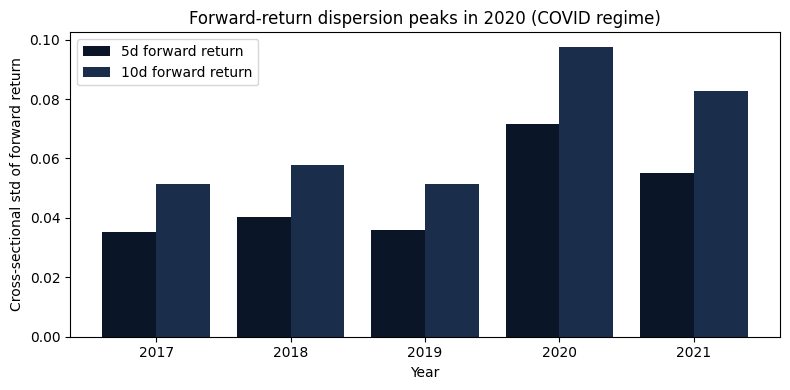

In [11]:
years = annual_stats["year"].to_list()
c5, c10 = ml4t_palette(2)[:2]
x = range(len(years))
width = 0.4

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    [i - width / 2 for i in x],
    annual_stats["ret_5d_std"].to_list(),
    width,
    label="5d forward return",
    color=c5,
)
ax.bar(
    [i + width / 2 for i in x],
    annual_stats["ret_10d_std"].to_list(),
    width,
    label="10d forward return",
    color=c10,
)
ax.set_xticks(list(x))
ax.set_xticklabels(years)
ax.set_xlabel("Year")
ax.set_ylabel("Cross-sectional std of forward return")
peak_year = years[int(annual_stats["ret_10d_std"].arg_max())]
ax.set_title(f"Forward-return dispersion peaks in {peak_year} (COVID regime)")
ax.legend()
fig.tight_layout()
plt.show()

## 5. Baseline IC (Quality Gate)

Compute cross-sectional IC of a simple momentum signal (21-day return)
against the primary 5d forward return. This sets the bar for Ch8 features:
any feature must beat this baseline to justify its complexity.

In [12]:
primary_label_col = f"fwd_ret_{PRIMARY_HORIZON}d"

baseline = daily.sort(["symbol", "timestamp"]).with_columns(
    (pl.col("close") / pl.col("close").shift(21).over("symbol") - 1).alias("mom_21d")
)

baseline_eval = baseline.select(["timestamp", "symbol", "mom_21d"]).join(
    labels.select(["timestamp", "symbol", primary_label_col]).drop_nulls(),
    on=["timestamp", "symbol"],
    how="inner",
)

baseline_ic = (
    baseline_eval.filter(pl.col("mom_21d").is_not_null() & pl.col(primary_label_col).is_not_null())
    .group_by("timestamp")
    .agg(
        pl.corr("mom_21d", primary_label_col, method="spearman").alias("ic"),
        pl.len().alias("n_obs"),
    )
    .filter(pl.col("n_obs") >= 10)
    .drop_nulls("ic")
    .sort("timestamp")
)

baseline_ic_mean = float(baseline_ic["ic"].mean())
baseline_ic_std = float(baseline_ic["ic"].std())
baseline_ic_tstat = baseline_ic_mean / (baseline_ic_std / (len(baseline_ic) ** 0.5))

print(f"Baseline IC (mom_21d vs {primary_label_col}):")
print(f"  Mean IC: {baseline_ic_mean:.4f}")
print(f"  t-stat:  {baseline_ic_tstat:.2f}")
print(f"  N dates: {len(baseline_ic)}")

Baseline IC (mom_21d vs fwd_ret_5d):
  Mean IC: -0.0104
  t-stat:  -1.86
  N dates: 1233


## 6. Label Autocorrelation

Cross-sectional mean label autocorrelation at lag-1. High autocorrelation
from overlapping returns confirms that HAC standard errors are required
for IC inference in Ch8.

In [13]:
label_acf = (
    labels.select(["timestamp", primary_label_col])
    .drop_nulls()
    .group_by("timestamp")
    .agg(pl.col(primary_label_col).mean().alias("xs_mean"))
    .sort("timestamp")
)

lag1_acf = float(
    label_acf.with_columns(pl.col("xs_mean").shift(1).alias("xs_mean_lag1"))
    .drop_nulls()
    .select(pl.corr("xs_mean", "xs_mean_lag1"))
    .item()
)
n_dates = label_acf.height
n_eff = n_dates / PRIMARY_HORIZON  # Effective independent observations
n_eff_per_fold = n_eff / 2  # 2 CV folds

print(f"Label autocorrelation (lag-1 of xs mean): {lag1_acf:.4f}")
print(
    f"Effective sample size: N_eff ≈ {n_dates}/{PRIMARY_HORIZON} = {n_eff:.0f} "
    f"independent dates ({n_eff_per_fold:.0f} per CV fold)"
)
print("High autocorrelation confirms HAC adjustment needed for IC inference")

Label autocorrelation (lag-1 of xs mean): 0.7737
Effective sample size: N_eff ≈ 1254/5 = 251 independent dates (125 per CV fold)
High autocorrelation confirms HAC adjustment needed for IC inference


## 7. Save Labels and CV Configuration

Save all artifacts to the case study labels directory. The CV config comes
from `setup.yaml` via `make_wf_config()`.

In [14]:
label_key_cols = ["timestamp", "symbol"]

LABELS_DIR.mkdir(parents=True, exist_ok=True)

# Save individual label files
for h in ALL_HORIZONS:
    # Regression labels
    labels.select(label_key_cols + [f"fwd_ret_{h}d"]).drop_nulls().write_parquet(
        LABELS_DIR / f"fwd_ret_{h}d.parquet"
    )
    # Direction labels
    labels.select(label_key_cols + [f"fwd_dir_{h}d"]).drop_nulls().write_parquet(
        LABELS_DIR / f"fwd_dir_{h}d.parquet"
    )
    print(f"Saved fwd_ret_{h}d.parquet, fwd_dir_{h}d.parquet")

# Risk-adjusted labels
ra_col = f"fwd_ret_risk_adj_{PRIMARY_HORIZON}d"
labels.select(label_key_cols + [ra_col]).drop_nulls().write_parquet(
    LABELS_DIR / f"fwd_ret_risk_adj_{PRIMARY_HORIZON}d.parquet"
)
print(f"Saved fwd_ret_risk_adj_{PRIMARY_HORIZON}d.parquet")

# CV config from setup.yaml evaluation section
cv_config = make_wf_config("sp500_equity_option_analytics", label_horizon=f"{PRIMARY_HORIZON}D")
cv_config.to_json(CASE_DIR / "config" / "cv_config.json")
print(f"Saved cv_config.json (n_splits={cv_config.n_splits})")

Saved fwd_ret_5d.parquet, fwd_dir_5d.parquet
Saved fwd_ret_10d.parquet, fwd_dir_10d.parquet
Saved fwd_ret_risk_adj_5d.parquet


Saved cv_config.json (n_splits=2)


## Key Takeaways

1. **Two regression horizons** (5d, 10d) enable horizon exploration. The 5d
   baseline momentum IC computed above is weak (negative, t = -1.86), so the 10d
   variant is included to test whether a longer horizon -- which halves turnover
   and can capture slower-accruing VRP signal -- improves viability.

2. **Risk-adjusted labels** divide forward returns by trailing realized vol,
   identifying stocks with attractive risk-adjusted opportunities.

3. **Execution-consistent** convention (enter at t+1 open) eliminates
   intraday information leakage.

4. **Annual breakdown** shows 2020 COVID crash/recovery is the largest
   contributor to fold-1 test metrics -- report fold-level IC separately in
   downstream modeling.

**Next**: `03_financial_features.py` in Ch8 engineers IV surface features, VRP,
and equity momentum features using canonical loaders.